In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [4]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

C:\Users\MAQS\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9251 - loss: 0.2614
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9667 - loss: 0.1147
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9755 - loss: 0.0799
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9818 - loss: 0.0588
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9857 - loss: 0.0460


In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9775 - loss: 0.0714
Test Loss: 0.0714
Test Accuracy: 0.9775


In [11]:
predictions = model.predict(x_test)

print(predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)


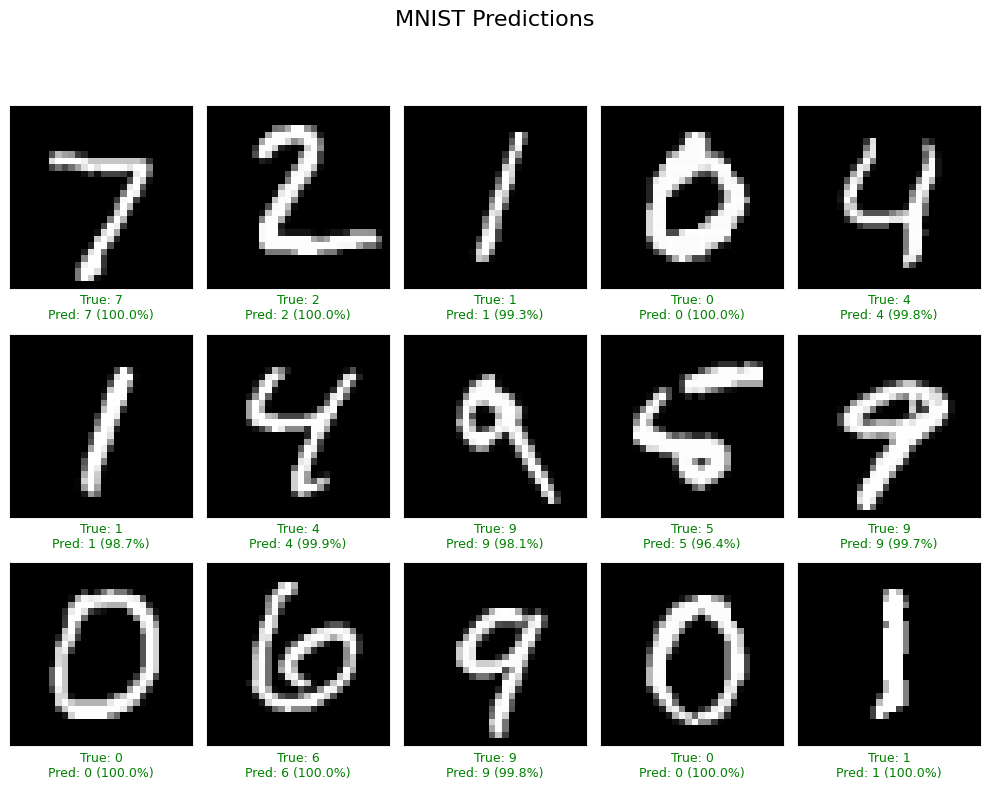

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_image_grid(images, true_labels, preds, rows=3, cols=5):
    plt.figure(figsize=(10, 8))

    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap="gray")
        predicted_label = np.argmax(preds[i])
        true_label = true_labels[i]
        confidence = np.max(preds[i]) * 100
        color = "green" if predicted_label == true_label else "red"
        plt.xlabel(
            f"True: {true_label}\nPred: {predicted_label} ({confidence:.1f}%)",
            color=color,
            fontsize=9
        )
    plt.suptitle("MNIST Predictions", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
plot_image_grid(x_test, y_test, predictions)